### Day 3
Goal: Understand Dimensionality Reduction Deeply


Converged in 2 iterations
Converged in 2 iterations


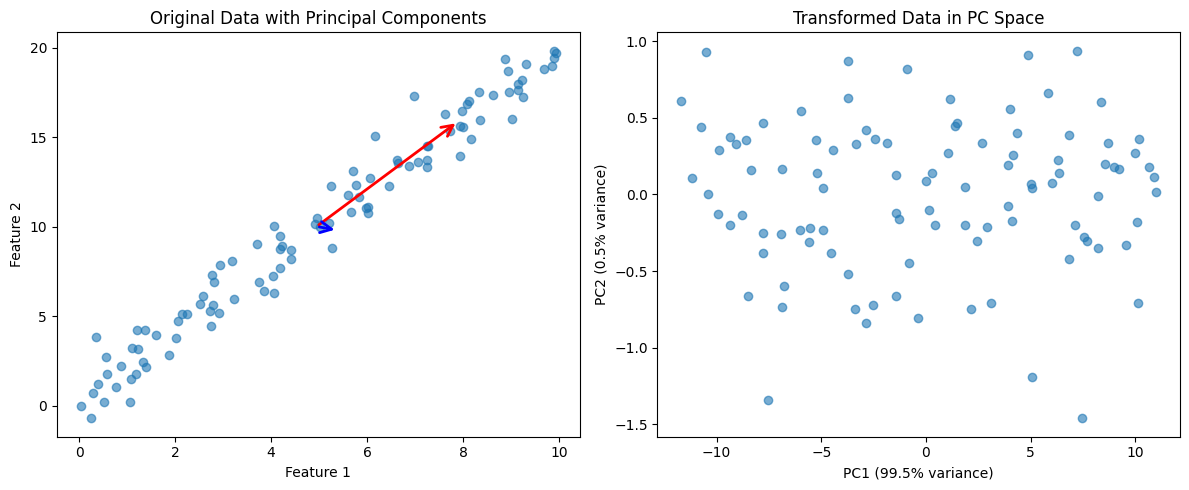

Dot Product: -1.674684520689777e-17
Converged in 2 iterations
Reconstruction Error:  0.1158
Explained variance ratio for pca_1d: [0.99462608]
Original data range - X[:, 0]: 0.03 to 9.93
Original data range - X[:, 1]: -0.71 to 19.83
Reconstructed range - X_reconstructed[:, 0]: -0.30 to 9.88
Reconstructed range - X_reconstructed[:, 1]: -0.43 to 19.84
X_1d range: -11.69 to 10.99
Original variance: 43.0892
Reconstructed variance: 42.8576
Ratio: 0.9946
pc1 variance: 42.85764998236644 eigenvalue: 42.85764998236644
Converged in 8 iterations
Converged in 2 iterations
[0.60741882 0.39258118]


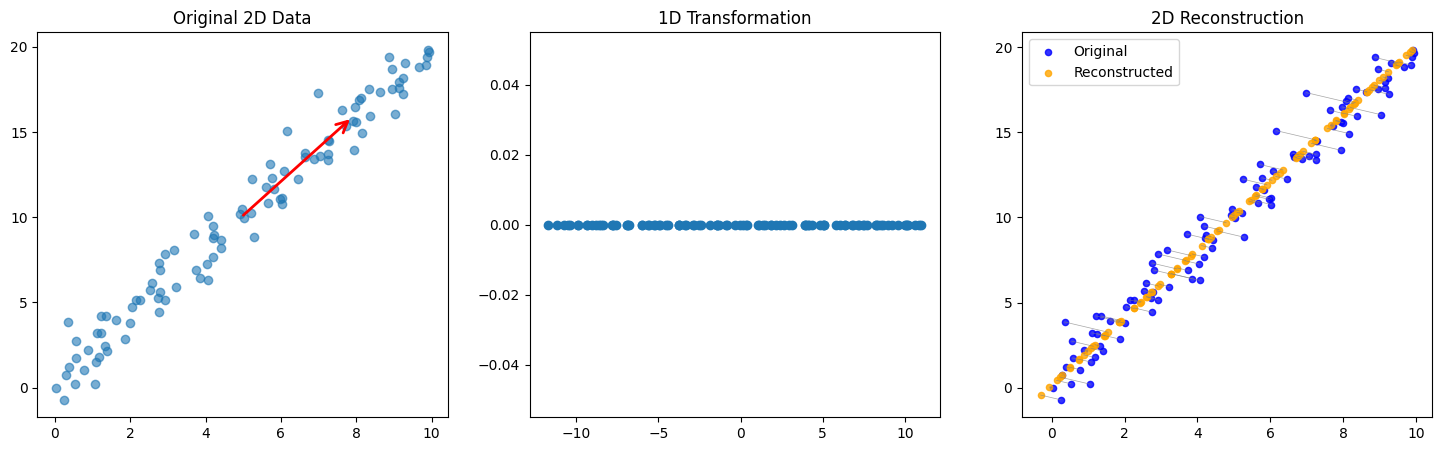

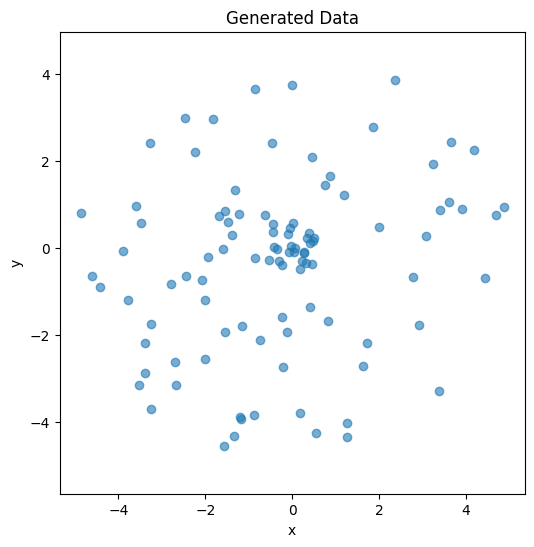

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
from matplotlib.patches import FancyArrowPatch
import sys
sys.path.append('../lib/linear_algebra')
from matrix import Matrix
from vector import Vector

class PCA:
    """
    Principal Component Analysis (PCA) for dimensionality reduction.

    PCA finds the directions (principal components) in your data that
    have the most variance. These directions are eigenvectors of the
    covariance matrix. By projecting data onto the top few principal
    components, we can reduce the dimensions while keeping most of
    the information.

    The Algorithm:
    1. Center the data (subtract the mean)
    2. Compute the covariance matrix
    3. Find eigenvectors and eigenvalues of covariance matrix
    4. Sort eigenvectors by eigenvalue (largest first)
    5. Keep top k eigenvectors as principal components
    6. Project data onto these components

    Attributes:
        n_components: Number of principal components to keep
        components_: The principal components (eigenvectors)
        mean_: Mean of the training data
        explained_variance_: Variance explained by each component (eigenvalues)
        explained_variance_ratio_: Proportion of variance explained

    Example:
        >>> X = np.random.randn(100,50) # 100 samples, 50 features
        >>> pca = PCA(n_components=2)
        >>> X_reduced = pca.fit_transform(X) # Now (100, 2)
        >>> Print(f"Kept {pca.explained_variance_ratio_.sum():.1%} of variance")
    """
    def __init__(self, n_components: int = 2):
        """
        Initialize PCA.

        Args:
            n_components: Number of principal components to keep
        """
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X: np.ndarray) -> 'PCA':
        """
        Fit PCA on data matrix X.

        This finds the principal components (directions of maximum
        variance) by computing eigenvectors of the covariance matrix.

        Args:
            X: Data matrix of shape (n_samples, n_features)

        Returns:
            self (for method chaining)
        
        Steps:
            1. Calculate the mean of each feature (column)
            2. Center the data by subtracting the mean
            3. Compute covariance matrix (X_Centered.T @  X_Centered) / (n-1)
            4. Compute eigenvectors and eigenvalues using np.linalg.eig()
            5. Sort eigenvectors by eigenvalue (descending)
            6. Store top n_components eigenvectors as components_
            7. Store corresponding eigenvalues as explained_variance_
            8. Calculate explained_variance_ratio_
        """
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_ #fit data onto mean
        cov_matrix = X_centered.T@X_centered / X.shape[0] #compute covar matrix
        cov_matrix = Matrix(cov_matrix.tolist())
        eigenvalues, eigenvectors = zip(*cov_matrix.find_top_k_eigenvalues(self.n_components)) #find top eigenvectors/values
        self.components_ = np.array([vec.components for vec in eigenvectors]) # create list of eigenvectors
        self.explained_variance_ = np.array(eigenvalues) #get variance values from eigenvalues
        self.explained_variance_ratio_ = self.explained_variance_ / X_centered.var(axis=0).sum() #compute variance ratio
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Project data onto principal components.

        After fitting, this transforms data from original high-dimensional space to the
        lower-dimensional principal component space.

        Args:
            X: Data matrix of shape (n_samples, n_features)

        Returns:
            X_transformed = (X - mean) @ components.T

        This is a matrix multiplication where:
        - Each row of X is a data point
        - Each row of components is a principal component direction
        - Result: coordinates of each point in the PC space
        """
        X_centered = X - self.mean_ # align new data with training coordinate system
        X_transformed = X_centered@self.components_.T #project from high-dim space to low-dim PC space
        return X_transformed

    def fit_transform(self, X:np.ndarray) -> np.ndarray:
        """
        Fit PCA and transform in one step

        Args:
            X: Data matrix

        Returns:
            X_Transformed: Projected data
        """
        return self.fit(X).transform(X)

    def inverse_transform(self, X_transformed: np.ndarray) -> np.ndarray:
        """
        Transform data back to original space.

        This reconstructs the original data from the principal components.
        If n_components < n_features this is a lossy reconstruction.
        (you lose information from discarded components)

        Args:
            X_transformed: Data in PC space (n_samples, n_components)

        Returns: 
            X_reconstructed: Data in original space (n_samples, n_features)

        Mathematical Operation:
            X_reconstructed = X_transformed @ components + mean
        """
        X_centered = (X_transformed@self.components_) #un project the transformed data
        X_reconstructed = X_centered + self.mean_ #uncenter the data
        return X_reconstructed

# Testing
# create correlated 2D Data
np.random.seed(42)
n_samples = 100
t = np.linspace(0,10, n_samples)
x = t + np.random.normal(0, 0.5, n_samples)
y = 2*t + np.random.normal(0, 0.5, n_samples)
X = np.column_stack([x,y])

#Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Visualize
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Subplot 1: Original data with BOTH arrows
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6)
axes[0].set_title("Original Data with Principal Components")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Arrow 1 (PC1) - RED
start = pca.mean_
end = pca.mean_ + pca.components_[0] * np.sqrt(pca.explained_variance_[0])
arrow1 = FancyArrowPatch(start, end, arrowstyle='->', linewidth=2, color='red', mutation_scale=20)
axes[0].add_patch(arrow1)

# Arrow 2 (PC2) - BLUE
arrow2 = FancyArrowPatch(
  pca.mean_,
  pca.mean_ + pca.components_[1] * np.sqrt(pca.explained_variance_[1]),
  arrowstyle='->',
  linewidth=2,
  color='blue',
  mutation_scale=20
)
axes[0].add_patch(arrow2)

# Subplot 2: Transformed data
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
axes[1].set_title("Transformed Data in PC Space")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")

plt.tight_layout()
plt.show()

dot_product = pca.components_[0] @ pca.components_[1]
print(f"Dot Product: {dot_product}")

#reduce to 1D
pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X)

#Reconstruct from 1D:
X_reconstructed = pca_1d.inverse_transform(X_1d)

# 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6)
axes[0].set_title("Original 2D Data")

# Show which direction we're keeping
arrow1 = FancyArrowPatch(
  pca_1d.mean_,
  pca_1d.mean_ + pca_1d.components_[0] * np.sqrt(pca_1d.explained_variance_[0]),
  arrowstyle='->',
  linewidth=2,
  color='red',
  mutation_scale=20
)
axes[0].add_patch(arrow1)

axes[1].scatter(X_1d[:,0], np.zeros(len(X_1d)))
axes[1].set_title("1D Transformation")

for i in range(len(X)):
    axes[2].plot([X[i, 0], X_reconstructed[i, 0]],
                 [X[i,1], X_reconstructed[i,1]],
                 'gray', alpha=0.7, linewidth=0.5)
axes[2].scatter(X[:, 0], X[:, 1], alpha=0.8, label='Original', color='blue', s=20)
axes[2].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.8, label='Reconstructed', color='orange', s=20)
axes[2].legend()
axes[2].set_title("Original vs Reconstructed (with error lines)")
axes[2].set_title("2D Reconstruction")
axes[2].legend()

reconstruction_error = np.mean((X-X_reconstructed)**2)
print(f"Reconstruction Error: {reconstruction_error: .4f}")
print(f"Explained variance ratio for pca_1d: {pca_1d.explained_variance_ratio_}")
print(f"Original data range - X[:, 0]: {X[:, 0].min():.2f} to {X[:, 0].max():.2f}")
print(f"Original data range - X[:, 1]: {X[:, 1].min():.2f} to {X[:, 1].max():.2f}")
print(f"Reconstructed range - X_reconstructed[:, 0]: {X_reconstructed[:, 0].min():.2f} to {X_reconstructed[:, 0].max():.2f}")
print(f"Reconstructed range - X_reconstructed[:, 1]: {X_reconstructed[:, 1].min():.2f} to {X_reconstructed[:, 1].max():.2f}")
print(f"X_1d range: {X_1d[:, 0].min():.2f} to {X_1d[:, 0].max():.2f}")

print(f"Original variance: {X.var(axis=0).sum():.4f}")
print(f"Reconstructed variance: {X_reconstructed.var(axis=0).sum():.4f}")
print(f"Ratio: {X_reconstructed.var(axis=0).sum() / X.var(axis=0).sum():.4f}")

pc1_coords = X_pca[:,0]
variance = pc1_coords.var()
print(f"pc1 variance: {variance} eigenvalue: {pca.explained_variance_[0]}")

theta = np.random.uniform(0,2*np.pi, n_samples)
radius = 5
r = np.random.uniform(0, radius, n_samples)
x = r * np.cos(theta)
y = r * np.sin(theta)
X = np.column_stack([x,y])

circular_pca = PCA(n_components=2)
circular_pca.fit_transform(X)

print(circular_pca.explained_variance_ratio_)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.axis('equal')  # Important! Makes circles look circular
plt.title("Generated Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()





    


        
        
        
        
        
            